In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba

/iridisfs/home/lhl1g23/ssm/mamba


In [2]:
from models.dataloaders.dataloaders import get_cifar
train, test = get_cifar()

X, y = next(iter(train))
X, y = X.to("cuda"), y.to("cuda")

/home/lhl1g23/.conda/envs/mamba/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from train.train_classifier import MambaClassifierTrainer
from mamba_ssm.modules.mamba import MambaConfig
from omegaconf import OmegaConf
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)

patch_size = 1

config = OmegaConf.load(f"models/configs/cifar/cifar_{patch_size}_patchsize.yaml")

model = MambaClassifierTrainer.load_from_checkpoint(
    f"/scratch/lhl1g23/mamba/checkpoints/cifar/{patch_size}_patchsize_new/last.ckpt",
    data="cifar",
    model_config=config.model,
    mamba_config=config.mamba
)

model.eval()

pred = torch.argmax(model(X), dim=1)

params = next(model.classifier.get_params(X))

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']
y_out = params['y_out']

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


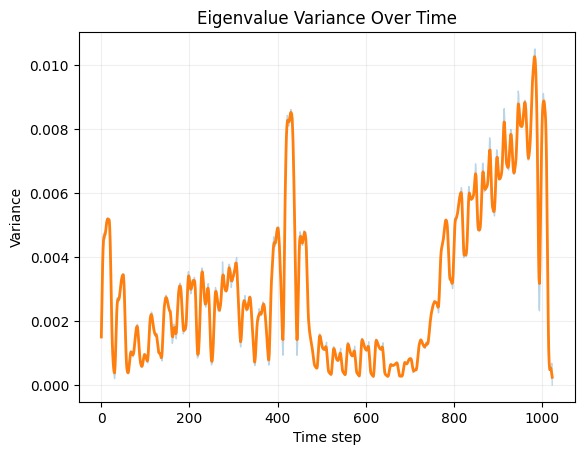

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_variance(M, ax, b_dim, window=100):
    data = M[b_dim].cpu().float().numpy()
    l = len(data)
    reshaped = data.reshape(l, -1)

    full_windows = np.lib.stride_tricks.sliding_window_view(reshaped, window, axis=0)
    variances_full = full_windows.var(axis=-1).mean(axis=-1)

    tail = np.array([
        reshaped[t:].var(axis=0).mean()
        for t in range(l - window + 1, l)
    ])

    variances = np.concatenate([variances_full, tail])

    kernel = np.ones(5) / 5
    smooth = np.convolve(variances, kernel, mode="same")

    x = np.arange(l)
    ax.plot(x, variances, alpha=0.3, linewidth=1)
    ax.plot(x, smooth, linewidth=2)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Variance")
    ax.set_title("Eigenvalue Variance Over Time")
    ax.grid(alpha=0.2)

plot_variance(dA, plt.gca(), 0, window=20)

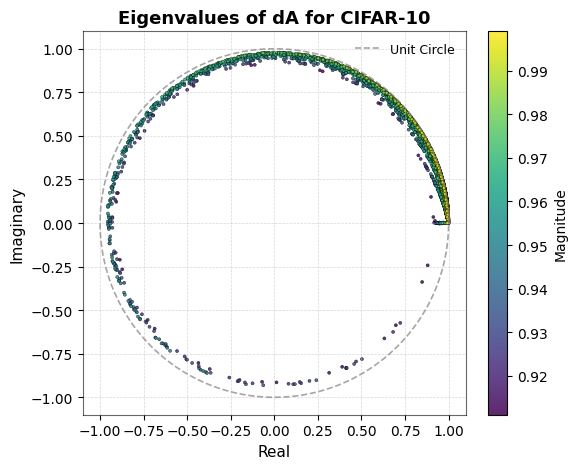

In [ ]:
from analyse.utils.plots import plot_eigen, plot_frequency_repsponse_one_step, plot_z_transform_one_step, plot_jacobian_dy_dt, plot_variance, plot_real_eigen

plot_eigen(torch.flatten(dA[0, 0, :, :].cpu()), plt.gca(), s=5, title="Eigenvalues of dA for CIFAR-10")

In [ ]:
plot_variance(dA, plt.gca(), window=5)

TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

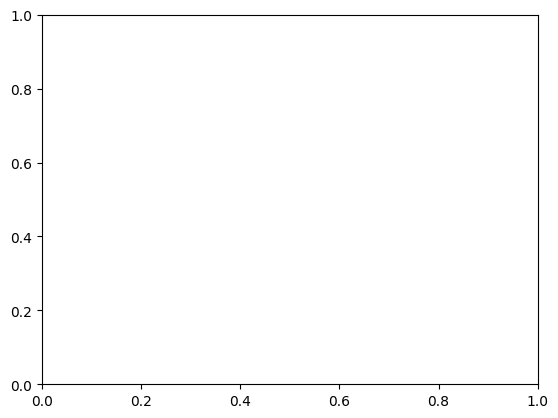

In [7]:
plot_variance(dA, plt.gca(), b_dim=0, window=5)